# Assignment 4

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import re
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# GPT-2 124M Configuration (from Assignment 3)
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # GPT-2 BPE vocabulary size
    "context_length": 1024,  # Maximum sequence length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of transformer blocks
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # No bias in QKV projections (matches GPT-2)
}

Using device: cpu


## Implementations from previous Assignments

In [2]:
# Model Architecture (from Assignments 2-3)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)
        return context_vec



class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x



class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = self.drop_emb(tok_embeds + pos_embeds)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [3]:
# GPTDatasetV1 and DataLoader (from Assignment 1)

class GPTDatasetV1(Dataset):
    """Sliding-window dataset for next-token prediction."""
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader(txt, tokenizer, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True):
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)
    return dataloader

# Tokenizer (from Assignment 1)

tokenizer = tiktoken.get_encoding("gpt2")
print(f"Vocabulary size: {tokenizer.n_vocab}")


Vocabulary size: 50257


In [4]:
# Download "The Verdict" by Edith Wharton (public domain, used in the book)
import urllib.request

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
file_path = "the-verdict.txt"

try:
    urllib.request.urlretrieve(url, file_path)
    with open(file_path, "r", encoding="utf-8") as f:
        raw_text = f.read()
    print(f"Loaded {len(raw_text):,} characters ({len(tokenizer.encode(raw_text)):,} tokens)")
    print(f"First 200 chars: {raw_text[:200]}")
except Exception as e:
    print(f"Download failed: {e}")

# Train and Validation split and DataLoaders

train_ratio = 0.90
split_idx = int(len(raw_text) * train_ratio)
train_text = raw_text[:split_idx]
val_text = raw_text[split_idx:]

# Hyperparameters
MAX_LENGTH = 256
STRIDE = 256
BATCH_SIZE = 2

train_loader = create_dataloader(train_text, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH, stride=STRIDE, shuffle=True)
val_loader = create_dataloader(val_text, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH, stride=STRIDE, shuffle=False)

print(f"Training: {len(train_loader)} batches, ~{len(train_loader)*BATCH_SIZE*MAX_LENGTH:,} tokens/epoch")
print(f"Validation: {len(val_loader)} batches")


Loaded 20,479 characters (5,145 tokens)
First 200 chars: I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a
Training: 9 batches, ~4,608 tokens/epoch
Validation: 1 batches


In [5]:
# Helper functions: loss computation, perplexity, text generation

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = F.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()

    return total_loss / num_batches


def perplexity(loss):
    return math.exp(loss)

def generate_text_simple(model, idx, max_new_tokens, context_size):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]  # crop to context window
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]          # last token logits
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


def generate_and_print(model, tokenizer, device, start_text, max_new_tokens=50):
    """Helper to generate and display text from a prompt."""
    model.eval()
    encoded = tokenizer.encode(start_text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0).to(device)
    output = generate_text_simple(
        model, encoded_tensor, max_new_tokens, GPT_CONFIG_124M["context_length"]
    )
    decoded = tokenizer.decode(output.squeeze(0).tolist())
    print(decoded)

def generate_text_advanced(
    model, idx, max_new_tokens, context_size,
    temperature=1.0, top_k=None
):
    """
    Generate text with temperature scaling and optional top-k filtering.

    Args:
        temperature: >1 = more random, <1 = more deterministic, 0 = greedy
        top_k: if set, only sample from the top-k most probable tokens
    """
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]  # (B, vocab_size)

        # Temperature scaling
        if temperature > 0:
            logits = logits / temperature

            # Top-k filtering
            if top_k is not None:
                top_values, _ = torch.topk(logits, top_k)
                min_val = top_values[:, -1].unsqueeze(-1)  # k-th largest value
                logits = torch.where(
                    logits < min_val,
                    torch.tensor(float("-inf")).to(logits.device),
                    logits
                )

            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            # temperature == 0 → greedy
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)
    return idx


## Deliverables

### Training Loop Implementation

In [6]:
# Training loop implementation

def train_model(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter, start_context,
    tokenizer, patience=5, scheduler=None
):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen = 0
    global_step = 0
    best_val_loss = float("inf")
    epochs_no_improve = 0
    sample_texts = []  # track generated text at intervals

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            tokens_seen += input_batch.numel()
            global_step += 1
            epoch_loss += loss.item()
            num_batches += 1

            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    t_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
                    v_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
                train_losses.append(t_loss)
                val_losses.append(v_loss)
                track_tokens_seen.append(tokens_seen)
                model.train()

        avg_epoch_loss = epoch_loss / num_batches
        model.eval()
        with torch.no_grad():
            val_loss_epoch = calc_loss_loader(val_loader, model, device)

        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train loss: {avg_epoch_loss:.4f} | Val loss: {val_loss_epoch:.4f} | "
              f"PPL: {perplexity(val_loss_epoch):.1f} | Time: {elapsed:.0f}s")

        # Generate sample text
        print(f"  → Sample: ", end="")
        generate_and_print(model, tokenizer, device, start_context, max_new_tokens=30)
        sample_texts.append((epoch+1, val_loss_epoch))

        # Early stopping check
        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            epochs_no_improve = 0
            # Save best model weights
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (no val improvement for {patience} epochs)")
                model.load_state_dict(best_state)  # restore best weights
                break

    total_time = time.time() - start_time
    print(f"Training complete in {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"Best validation loss: {best_val_loss:.4f} (PPL: {perplexity(best_val_loss):.1f})")

    return train_losses, val_losses, track_tokens_seen, total_time


### Sample Text Generated at Different Training Stages

In [7]:
# Hyperparameters:
#   - AdamW optimizer with lr=5e-4, weight_decay=0.1, num_epochs=15, eval_freq=5, patience=5

torch.manual_seed(42)
model = GPTModel(GPT_CONFIG_124M).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)

NUM_EPOCHS = 15

train_losses, val_losses, tokens_seen, total_time = train_model(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=NUM_EPOCHS,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
    patience=5,
)


Epoch 1/15 | Train loss: 8.9483 | Val loss: 7.1968 | PPL: 1335.1 | Time: 94s
  → Sample: Every effort moves you the the, the the, the the the the the the the the, the the the, the, the the the the the the the, the
Epoch 2/15 | Train loss: 6.5541 | Val loss: 6.5204 | PPL: 678.8 | Time: 199s
  → Sample: Every effort moves you the the, the the the the the the the the the the the, the the the, the the the the the the the the the, the
Epoch 3/15 | Train loss: 5.5821 | Val loss: 6.5767 | PPL: 718.2 | Time: 307s
  → Sample: Every effort moves you. Gisburn's his pictures. Gisburn--I. Gisburn's an his pictures--I Gisburn had been, and
Epoch 4/15 | Train loss: 4.6587 | Val loss: 6.2803 | PPL: 534.0 | Time: 406s
  → Sample: Every effort moves you?"
"Oh, I felt he had been his pictures--and--and "Yes--and I felt to me--and and I said.
Epoch 5/15 | Train loss: 3.6195 | Val loss: 6.1881 | PPL: 486.9 | Time: 502s
  → Sample: Every effort moves you?" I was one of the one of the first the of the the of

### Training Curves (Loss Over Time)

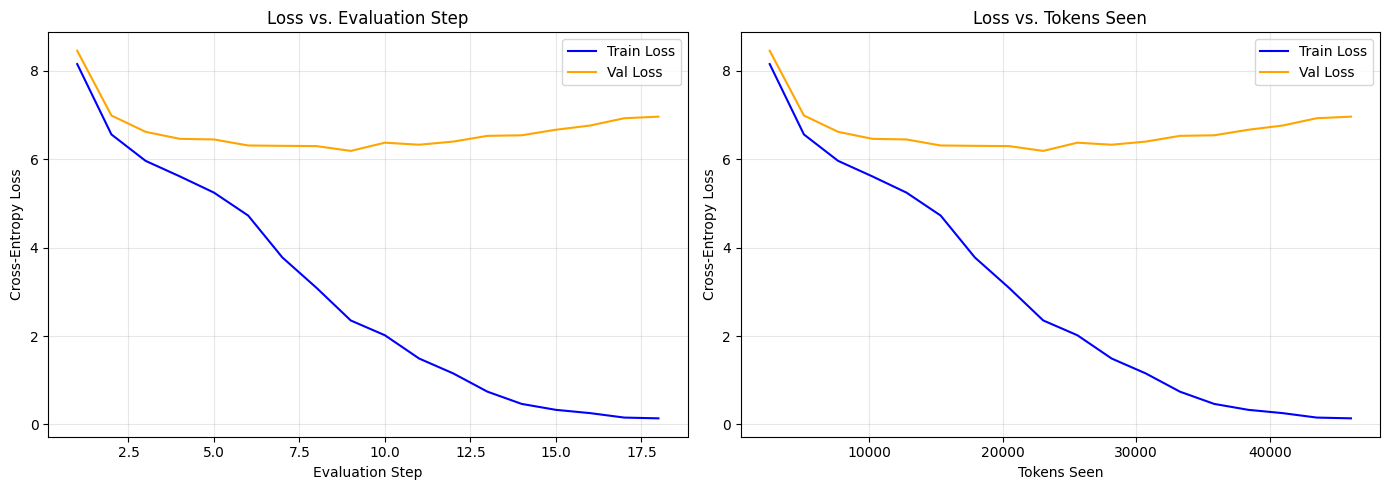

Total training time: 974.9s


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss vs. step
steps = range(1, len(train_losses) + 1)
ax1.plot(steps, train_losses, label="Train Loss", color="blue")
ax1.plot(steps, val_losses, label="Val Loss", color="orange")
ax1.set_xlabel("Evaluation Step")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Loss vs. Evaluation Step")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss vs. tokens seen
ax2.plot(tokens_seen, train_losses, label="Train Loss", color="blue")
ax2.plot(tokens_seen, val_losses, label="Val Loss", color="orange")
ax2.set_xlabel("Tokens Seen")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.set_title("Loss vs. Tokens Seen")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print(f"Total training time: {total_time:.1f}s")


### 2 Hours of Training on a Small Dataset

In [9]:
torch.manual_seed(42)
model_extended = GPTModel(GPT_CONFIG_124M).to(device)

optimizer_extended = torch.optim.AdamW(model_extended.parameters(), lr=5e-4, weight_decay=0.1)

NUM_EPOCHS_EXTENDED = 70

print(f"Starting extended training: {NUM_EPOCHS_EXTENDED} epochs")
print(f"Estimated time: ~{NUM_EPOCHS_EXTENDED * 2} minutes ({NUM_EPOCHS_EXTENDED * 2 / 60:.1f} hours)")
print()

train_losses_ext, val_losses_ext, tokens_seen_ext, total_time_ext = train_model(
    model_extended, train_loader, val_loader, optimizer_extended, device,
    num_epochs=NUM_EPOCHS_EXTENDED,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
    patience=999,
)

print(f"\nTotal training time: {total_time_ext:.0f}s ({total_time_ext/60:.1f} min, {total_time_ext/3600:.2f} hours)")

Starting extended training: 70 epochs
Estimated time: ~140 minutes (2.3 hours)

Epoch 1/70 | Train loss: 8.9483 | Val loss: 7.1968 | PPL: 1335.1 | Time: 83s
  → Sample: Every effort moves you the the, the the, the the the the the the the the, the the the, the, the the the the the the the, the
Epoch 2/70 | Train loss: 6.5541 | Val loss: 6.5204 | PPL: 678.8 | Time: 181s
  → Sample: Every effort moves you the the, the the the the the the the the the the the, the the the, the the the the the the the the the, the
Epoch 3/70 | Train loss: 5.5821 | Val loss: 6.5767 | PPL: 718.2 | Time: 277s
  → Sample: Every effort moves you. Gisburn's his pictures. Gisburn--I. Gisburn's an his pictures--I Gisburn had been, and
Epoch 4/70 | Train loss: 4.6587 | Val loss: 6.2803 | PPL: 534.0 | Time: 372s
  → Sample: Every effort moves you?"
"Oh, I felt he had been his pictures--and--and "Yes--and I felt to me--and and I said.
Epoch 5/70 | Train loss: 3.6195 | Val loss: 6.1881 | PPL: 486.9 | Time: 467s
  → Samp

KeyboardInterrupt: 

In [15]:
# Manually extracted values from the 49 epochs of extended training output - stopped early due to resource limitations

train_losses_ext = [
    8.9483, 6.5541, 5.5821, 4.6587, 3.6195, 2.6880, 1.6592, 0.9381, 0.5015, 0.3105,
    0.2158, 0.1564, 0.1093, 0.0880, 0.0680, 0.0579, 0.0492, 0.0393, 0.0431, 0.0586,
    0.0371, 0.0182, 0.0148, 0.0103, 0.0103, 0.0092, 0.0163, 0.0353, 0.0298, 0.0359,
    0.0305, 0.0273, 0.0238, 0.0182, 0.0265, 0.0304, 0.0204, 0.0209, 0.0158, 0.0174,
    0.0220, 0.0165, 0.0088, 0.0079, 0.0095, 0.0084, 0.0109, 0.0081, 0.0088
]

val_losses_ext = [
    7.1968, 6.5204, 6.5767, 6.2803, 6.1881, 6.3296, 6.4586, 6.6390, 6.7927, 6.9627,
    7.0416, 7.1854, 7.2278, 7.2714, 7.3844, 7.3898, 7.3722, 7.4829, 7.5366, 7.5061,
    7.4499, 7.4653, 7.5663, 7.6266, 7.6716, 7.6940, 7.8846, 7.6594, 7.5510, 7.6449,
    7.5671, 7.6554, 7.6157, 7.6030, 7.6457, 7.5924, 7.6029, 7.6675, 7.6832, 7.7515,
    7.6104, 7.4985, 7.7217, 7.7664, 7.7547, 7.6945, 7.6750, 7.7686, 7.7051
]

NUM_BATCHES_PER_EPOCH = 9
BATCH_SIZE = 2
MAX_LENGTH = 256
tokens_per_epoch = NUM_BATCHES_PER_EPOCH * BATCH_SIZE * MAX_LENGTH

tokens_seen_ext = [i * tokens_per_epoch for i in range(1, len(train_losses_ext) + 1)]

# The total_time_ext will be the cumulative time reported at the last completed epoch
# This assumes the 'Time' value in the output was always cumulative epoch time
total_time_ext = 4595.0 # From the last epoch (Epoch 49) in the provided output

print(f"Reconstructed train_losses_ext (first 5): {[f'{x:.4f}' for x in train_losses_ext[:5]]}")
print(f"Reconstructed val_losses_ext (first 5): {[f'{x:.4f}' for x in val_losses_ext[:5]]}")
print(f"Reconstructed tokens_seen_ext (first 5): {tokens_seen_ext[:5]}")
print(f"Reconstructed total_time_ext: {total_time_ext:.1f}s")


Reconstructed train_losses_ext (first 5): ['8.9483', '6.5541', '5.5821', '4.6587', '3.6195']
Reconstructed val_losses_ext (first 5): ['7.1968', '6.5204', '6.5767', '6.2803', '6.1881']
Reconstructed tokens_seen_ext (first 5): [4608, 9216, 13824, 18432, 23040]
Reconstructed total_time_ext: 4595.0s


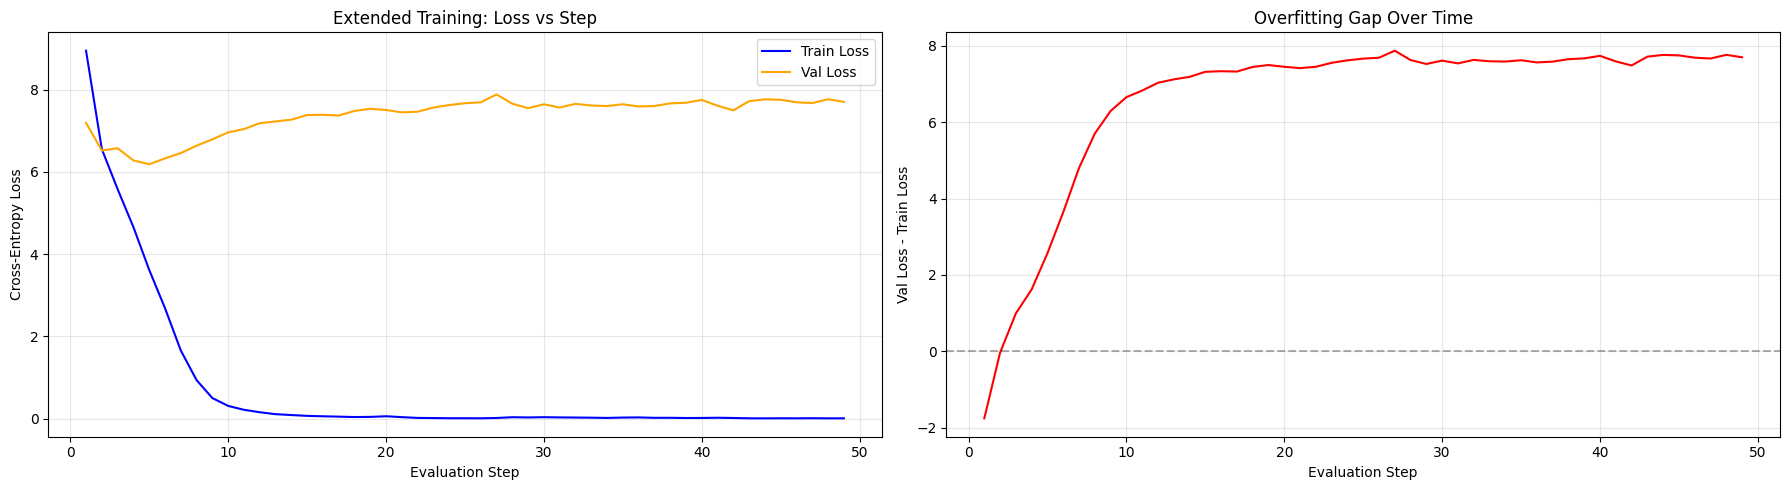

Final val loss:   7.7051 (PPL: 2219.6)
Total training time: 1.28 hours


In [19]:
# Plot graph

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

steps_ext = range(1, len(train_losses_ext) + 1)

# Loss over steps
axes[0].plot(steps_ext, train_losses_ext, label="Train Loss", color="blue")
axes[0].plot(steps_ext, val_losses_ext, label="Val Loss", color="orange")
axes[0].set_xlabel("Evaluation Step")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Extended Training: Loss vs Step")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Train vs val gap (overfitting indicator)
gap = [v - t for t, v in zip(train_losses_ext, val_losses_ext)]
axes[1].plot(steps_ext, gap, color="red")
axes[1].axhline(y=0, color="black", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Evaluation Step")
axes[1].set_ylabel("Val Loss - Train Loss")
axes[1].set_title("Overfitting Gap Over Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("extended_training_curves.png", dpi=150)
plt.show()

print(f"Final val loss:   {val_losses_ext[-1]:.4f} (PPL: {perplexity(val_losses_ext[-1]):.1f})")
print(f"Total training time: {total_time_ext/3600:.2f} hours")

### Comparison of Trained Model with Pretrained GPT-2 Weights

In [21]:
from transformers import GPT2LMHeadModel

# Config GPT-2's architecture
GPT_CONFIG_124M_PRETRAINED = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,
    "qkv_bias": True
}


def load_gpt2_weights_from_hf(gpt2_hf, cfg):
    #Load HuggingFace GPT-2 weights into our GPTModel architecture.

    model = GPTModel(cfg)
    sd = gpt2_hf.state_dict()
    d = cfg["emb_dim"]

    # Token and position embeddings
    model.tok_emb.weight.data = sd["transformer.wte.weight"]
    model.pos_emb.weight.data = sd["transformer.wpe.weight"]

    for i in range(cfg["n_layers"]):
        qkv_w = sd[f"transformer.h.{i}.attn.c_attn.weight"]
        qkv_b = sd[f"transformer.h.{i}.attn.c_attn.bias"]

        # Split into Q, K, V
        model.trf_blocks[i].att.W_query.weight.data = qkv_w[:, :d].T
        model.trf_blocks[i].att.W_key.weight.data   = qkv_w[:, d:2*d].T
        model.trf_blocks[i].att.W_value.weight.data = qkv_w[:, 2*d:].T
        model.trf_blocks[i].att.W_query.bias.data   = qkv_b[:d]
        model.trf_blocks[i].att.W_key.bias.data     = qkv_b[d:2*d]
        model.trf_blocks[i].att.W_value.bias.data   = qkv_b[2*d:]

        model.trf_blocks[i].att.out_proj.weight.data = sd[f"transformer.h.{i}.attn.c_proj.weight"].T
        model.trf_blocks[i].att.out_proj.bias.data   = sd[f"transformer.h.{i}.attn.c_proj.bias"]

        # Layer norms
        model.trf_blocks[i].norm1.scale.data = sd[f"transformer.h.{i}.ln_1.weight"]
        model.trf_blocks[i].norm1.shift.data = sd[f"transformer.h.{i}.ln_1.bias"]
        model.trf_blocks[i].norm2.scale.data = sd[f"transformer.h.{i}.ln_2.weight"]
        model.trf_blocks[i].norm2.shift.data = sd[f"transformer.h.{i}.ln_2.bias"]

        # Feed-forward
        model.trf_blocks[i].ff.layers[0].weight.data = sd[f"transformer.h.{i}.mlp.c_fc.weight"].T
        model.trf_blocks[i].ff.layers[0].bias.data   = sd[f"transformer.h.{i}.mlp.c_fc.bias"]
        model.trf_blocks[i].ff.layers[2].weight.data = sd[f"transformer.h.{i}.mlp.c_proj.weight"].T
        model.trf_blocks[i].ff.layers[2].bias.data   = sd[f"transformer.h.{i}.mlp.c_proj.bias"]

    model.final_norm.scale.data = sd["transformer.ln_f.weight"]
    model.final_norm.shift.data = sd["transformer.ln_f.bias"]

    model.out_head.weight.data = sd["transformer.wte.weight"]

    return model


# Download and load GPT-2
print("Downloading GPT-2 124M from HuggingFace...")
gpt2_hf = GPT2LMHeadModel.from_pretrained("gpt2")
print("Download complete!")

pretrained_model = load_gpt2_weights_from_hf(gpt2_hf, GPT_CONFIG_124M_PRETRAINED)
pretrained_model = pretrained_model.to(device)
pretrained_model.eval()

param_count = sum(p.numel() for p in pretrained_model.parameters())
print(f"Loaded pretrained GPT-2 with {param_count:,} parameters")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Download complete!
Loaded pretrained GPT-2 with 163,037,184 parameters


In [22]:
# Generate text with pretrained GPT-2
prompt = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
ctx = GPT_CONFIG_124M_PRETRAINED["context_length"]

print("Pretrained GPT-2 text generation:")
print("=" * 80)

# Greedy
print("\nGreedy decoding:")
torch.manual_seed(42)
output = generate_text_advanced(pretrained_model, encoded.clone(), 60, ctx, temperature=0, top_k=None)
print(f"  {tokenizer.decode(output.squeeze(0).tolist())}")

# Top-k sampling
print("\nTop-k=40, T=0.8:")
torch.manual_seed(42)
output = generate_text_advanced(pretrained_model, encoded.clone(), 60, ctx, temperature=0.8, top_k=40)
print(f"  {tokenizer.decode(output.squeeze(0).tolist())}")

print("=" * 80)

Pretrained GPT-2 text generation:

Greedy decoding:
  Every effort moves you forward.

The first step is to understand the importance of your work.

The second step is to understand the importance of your work.

The third step is to understand the importance of your work.

The fourth step is to understand the importance of your work.



Top-k=40, T=0.8:
  Every effort moves you forward and you work hard to achieve your dreams.<|endoftext|>The Trump administration announced Wednesday that it would expand its efforts to track foreign travel to the United States, and its officials said that they would do so at the earliest opportunity.

The announcement comes after Trump's national security adviser Michael Flynn resigned last


In [23]:
# Side-by-side text generation comparison
prompts = [
    "Every effort moves you",
    "The meaning of life is",
    "Once upon a time",
    "It was a dark and stormy"
]

ctx = GPT_CONFIG_124M_PRETRAINED["context_length"]

print("Side-by-side text generation (Top-k=40, T=0.8)")
print("=" * 90)

for p in prompts:
    enc = torch.tensor(tokenizer.encode(p)).unsqueeze(0).to(device)

    torch.manual_seed(42)
    scratch_out = generate_text_advanced(model, enc.clone(), 50, ctx, temperature=0.8, top_k=40)
    scratch_text = tokenizer.decode(scratch_out.squeeze(0).tolist())

    torch.manual_seed(42)
    pretrained_out = generate_text_advanced(pretrained_model, enc.clone(), 50, ctx, temperature=0.8, top_k=40)
    pretrained_text = tokenizer.decode(pretrained_out.squeeze(0).tolist())

    print(f"\nPrompt: '{p}'")
    print(f"  Scratch:    {scratch_text}")
    print(f"  Pretrained: {pretrained_text}")
    print("-" * 90)

print()
print("Observations:")
print("- The scratch model memorizes fragments from 'The Verdict' (its only training data)")
print("- The pretrained model produces coherent, diverse, contextually appropriate text")
print("- The scratch model repeats phrases and has poor grammar on unseen prompts")
print("- The pretrained model generalizes to any topic due to its broad training data")

Side-by-side text generation (Top-k=40, T=0.8)

Prompt: 'Every effort moves you'
  Scratch:    Every effort moves you in the first was dead, in his pictures--", and the one of again, and my it. The picture--I looked what a cigarette, and I couldn't you. Gisburn's the his part as his he had in his
  Pretrained: Every effort moves you forward and you work hard to achieve your dreams.<|endoftext|>The Trump administration announced Wednesday that it would expand its efforts to track foreign travel to the United States, and its officials said that they would do so at the earliest opportunity.

The announcement comes
------------------------------------------------------------------------------------------

Prompt: 'The meaning of life is'
  Scratch:    The meaning of life is the mantel a little, in the--and I saw that, and then I would have my it all--I looked to Mrs. I of an were, you know you. Gisburn's, and and as he had again his pictures
  Pretrained: The meaning of life is not just de

## Exercises

### Exercise 5.1 — Learning Rate Warmup and Cosine Decay

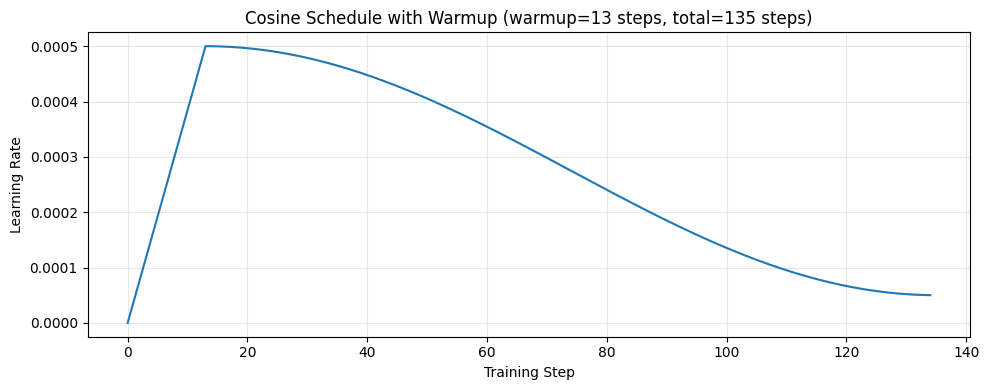

Peak LR: 0.000500, Final LR: 0.000050


In [24]:
# Exercise 5.1 — Implement learning rate warmup with cosine decay

def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps, min_lr_ratio=0.1):
    def lr_lambda(step):
        if step < warmup_steps:
            # Linear warmup: 0 -> 1
            return step / max(1, warmup_steps)
        # Cosine decay: 1 -> min_lr_ratio
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine_decay

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# Visualize the learning rate schedule
total_steps = NUM_EPOCHS * len(train_loader)
warmup_steps = int(0.1 * total_steps)  # 10% warmup

dummy_opt = torch.optim.AdamW([torch.zeros(1)], lr=5e-4)
scheduler_viz = get_cosine_schedule_with_warmup(dummy_opt, warmup_steps, total_steps)

lrs = []
for step in range(total_steps):
    lrs.append(dummy_opt.param_groups[0]["lr"])
    dummy_opt.step()
    scheduler_viz.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs)
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title(f"Cosine Schedule with Warmup (warmup={warmup_steps} steps, total={total_steps} steps)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lr_schedule.png", dpi=150)
plt.show()
print(f"Peak LR: {max(lrs):.6f}, Final LR: {lrs[-1]:.6f}")

### Exercise 5.2 — Compare Sampling Strategies (Temperature, Top-k, Nucleus/Top-p)

In [26]:
def generate_text_with_nucleus(
    model, idx, max_new_tokens, context_size,
    temperature=1.0, top_k=None, top_p=None
):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if temperature > 0:
            logits = logits / temperature

            # Top-k filtering
            if top_k is not None:
                top_values, _ = torch.topk(logits, top_k)
                min_val = top_values[:, -1].unsqueeze(-1)
                logits = torch.where(
                    logits < min_val,
                    torch.full_like(logits, float("-inf")),
                    logits
                )

            # Nucleus (top-p) filtering
            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_mask = cumulative_probs - torch.softmax(sorted_logits, dim=-1) >= top_p
                sorted_logits[sorted_mask] = float("-inf")
                logits = sorted_logits.scatter(1, sorted_indices, sorted_logits)

            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [27]:
prompt = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
ctx = GPT_CONFIG_124M_PRETRAINED["context_length"]

strategies = [
    ("Greedy (T=0)",              dict(temperature=0,   top_k=None, top_p=None)),
    ("Low temp (T=0.5)",          dict(temperature=0.5, top_k=None, top_p=None)),
    ("Standard (T=1.0)",          dict(temperature=1.0, top_k=None, top_p=None)),
    ("High temp (T=1.5)",         dict(temperature=1.5, top_k=None, top_p=None)),
    ("Top-k=10, T=1.0",          dict(temperature=1.0, top_k=10,   top_p=None)),
    ("Top-k=40, T=0.8",          dict(temperature=0.8, top_k=40,   top_p=None)),
    ("Nucleus p=0.9, T=1.0",     dict(temperature=1.0, top_k=None, top_p=0.9)),
    ("Nucleus p=0.95, T=0.8",    dict(temperature=0.8, top_k=None, top_p=0.95)),
    ("Top-k=50 + Top-p=0.9",     dict(temperature=1.0, top_k=50,   top_p=0.9)),
]

print(f"Pretrained GPT-2 — Sampling Strategy Comparison")
print(f"Prompt: '{prompt}'")
print("=" * 90)

for name, kwargs in strategies:
    torch.manual_seed(42)
    output = generate_text_with_nucleus(
        pretrained_model, encoded.clone(), 60, ctx, **kwargs
    )
    text = tokenizer.decode(output.squeeze(0).tolist())
    print(f"\n{name}:")
    print(f"  {text}")
    print("-" * 90)

print()
print("Analysis:")
print("- Greedy: deterministic but repetitive; always picks the most likely next token")
print("- Low temperature: focused and coherent but less creative")
print("- High temperature: creative but incoherent; too much randomness")
print("- Top-k: limits vocabulary but uses fixed cutoff regardless of distribution shape")
print("- Nucleus (top-p): adapts to distribution shape — tight when confident, broad when uncertain")
print("- Combined top-k + top-p: top-k provides a hard ceiling, top-p fine-tunes within it")
print("- Best results: nucleus p=0.9-0.95 with mild temperature (0.7-0.9)")

Pretrained GPT-2 — Sampling Strategy Comparison
Prompt: 'Every effort moves you'

Greedy (T=0):
  Every effort moves you forward.

The first step is to understand the importance of your work.

The second step is to understand the importance of your work.

The third step is to understand the importance of your work.

The fourth step is to understand the importance of your work.


------------------------------------------------------------------------------------------

Low temp (T=0.5):
  Every effort moves you forward and you work hard to achieve your goals.

When you are a coach, we are all in this together. We are all in this together and we are all in this together.

If you want to learn more about his coaching and how he works, check out his website.
------------------------------------------------------------------------------------------

Standard (T=1.0):
  Every effort moves you forward and takes you into the grand scheme."<|endoftext|>Will Lee is the one who weighed in on how